# Demo: Matching a pool to an *aggregate* target

`AggregateConstraintSatisfactionMatcher` selects a subset of a patient-level pool so that its
moments match a target known only through **summary statistics** -- e.g. a published trial's
Table 1 (means, proportions, sometimes standard deviations) -- rather than patient-level rows.

This notebook uses `pybalance.sim.generate_toy_dataset` and deliberately throws away the
patient-level target rows, keeping only a few summary numbers computed from them. That's the
only place target information comes from below.

The notebook walks through the moment-aware behavior of the matcher:
- a numeric feature's **mean** is always matched (it's required on `AggregateTarget`);
- its **variance** is *additionally* constrained only if you disclose a target `std` for it;
- disclosing a target `std` of `0` asks the solver for the **minimal-variance** subset for that
  feature -- a neat trick for finding the most homogeneous matching subgroup.

In [ ]:
import logging

import matplotlib.pyplot as plt
import pandas as pd

from pybalance.lp import AggregateConstraintSatisfactionMatcher
from pybalance.sim import generate_toy_dataset
from pybalance.utils import AggregateTarget, MatchingData, MatchingHeaders
from pybalance.visualization import (
    plot_categoric_features,
    plot_fractional_difference,
    plot_numeric_features,
)

%matplotlib inline

# show the matcher's CP-SAT solver output
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

## 1. Synthetic data, and "disclosing" only a few numbers

`generate_toy_dataset` returns patient-level `pool` and `target` populations -- entirely
simulated, no real patients. We keep the pool, but for the target we compute a handful of
summary statistics (as if reading them off a published Table 1) and then delete the
patient-level target rows, so nothing below this cell can accidentally use them.

In [3]:
m = generate_toy_dataset(n_pool=1000, n_target=100, seed=7)
pool = m.get_population("pool").drop(columns=[m.population_col])
target_patient_level = m.get_population("target").drop(columns=[m.population_col])

# Keep the feature set small so the solver stays quick for a demo.
headers = MatchingHeaders(numeric=["age", "weight", "height"], categoric=["gender", "country"])

print(f"pool:   {len(pool)} (synthetic) patients")
print(f"target: {len(target_patient_level)} (synthetic) patients -- patient-level rows discarded below")
pool[headers.all].head()

pool:   1000 (synthetic) patients
target: 100 (synthetic) patients -- patient-level rows discarded below


,gender,country,age,weight,height
0,0.0,4,69.436489,79.144533,155.189260
1,1.0,5,28.771438,97.734561,175.270602
2,0.0,2,62.640154,85.170055,136.648640
3,0.0,3,68.907932,90.705549,189.959952
4,1.0,3,49.571169,76.708193,133.787109


In [4]:
# "Disclosed" summary statistics -- pretend these are the only numbers a
# published Table 1 gives us about the target.
age_mean = float(target_patient_level["age"].mean())
age_std = float(target_patient_level["age"].std())
height_mean = float(target_patient_level["height"].mean())
height_std = float(target_patient_level["height"].std())
weight_mean = float(target_patient_level["weight"].mean())
weight_std = float(target_patient_level["weight"].std())
gender_rates = {
    k: float(v) for k, v in target_patient_level["gender"].value_counts(normalize=True).items()
}
country_rates = {
    k: float(v) for k, v in target_patient_level["country"].value_counts(normalize=True).items()
}
n_target = len(target_patient_level)

# From here on, only the disclosed numbers above exist -- no patient-level target data.
del target_patient_level

print(f"age:    mean={age_mean:.1f}, std={age_std:.1f}")
print(f"weight: mean={weight_mean:.1f}, std={weight_std:.1f}")
print(f"height: mean={height_mean:.1f}, std={height_std:.1f}")
print(f"gender: {gender_rates}")
print(f"country: {country_rates}")

age:    mean=50.8, std=15.0
weight: mean=82.1, std=18.7
height: mean=153.8, std=15.7
gender: {0.0: 0.55, 1.0: 0.45}
country: {1: 0.25, 2: 0.2, 4: 0.2, 5: 0.15, 3: 0.11, 0: 0.09}


## 2. A small helper

We'll build several `AggregateTarget`s below with different `std_mode`s, controlling whether/how
the numeric features' (`age`, `weight`, `height`) variances are constrained, and compare the
resulting matches. This helper builds the target, wraps it with the pool in a `MatchingData`, and
runs `AggregateConstraintSatisfactionMatcher`. `gender`'s and `country`'s rates are always
disclosed, as categoric baselines.

To inspect the results, use the library's own `MatchingData.describe()` -- it reports pool vs.
target side by side (N, categoric rates, numeric mean/std/quantiles) for both patient-level and
aggregate targets alike, so there's no need to write a custom summary printer.

In [5]:
def match_with_std_mode(std_mode):
    """
    Match `pool` to the disclosed target. std_mode controls whether/how the
    numeric features' (age, weight, height) variances are constrained:
      - "none"      -> no std disclosed for any numeric feature; only their
                        means are matched, so their spreads are unconstrained.
      - "disclosed" -> each numeric feature's actual std is disclosed too, so
                        the matcher additionally constrains its variance.
      - "zero"      -> every numeric feature's std is forced to 0, asking the
                        solver for the minimal-variance subset simultaneously
                        for all three.
    gender's and country's rates are always disclosed, as categoric baselines.
    """
    numeric = {
        "age": {"mean": age_mean},
        "weight": {"mean": weight_mean},
        "height": {"mean": height_mean},
    }
    if std_mode == "disclosed":
        numeric["age"]["std"] = age_std
        numeric["weight"]["std"] = weight_std
        numeric["height"]["std"] = height_std
    elif std_mode == "zero":
        numeric["age"]["std"] = 0.0
        numeric["weight"]["std"] = 0.0
        numeric["height"]["std"] = 0.0
    elif std_mode != "none":
        raise ValueError(f"Unknown std_mode: {std_mode!r}")

    target = AggregateTarget(
        n=n_target,
        numeric=numeric,
        categoric={"gender": gender_rates, "country": country_rates},
        headers=headers,
    )
    matching_data = MatchingData(pool=pool, target=target, headers=headers)
    matcher = AggregateConstraintSatisfactionMatcher(
        matching_data, time_limit=60, num_workers=1, verbose=True
    )
    return matching_data, matcher.match()

## 3. Use case 1 -- solve just for means

No numeric feature's std is passed to `AggregateTarget`, so the matcher is under no obligation to
control any of their spreads -- only `age`, `weight` and `height`'s means (and `gender`/`country`'s
rates) are constrained. Expect all three numeric features' matched stds to land wherever an
unconstrained mean-match happens to leave them.

In [6]:
before_a, after_a = match_with_std_mode("none")

Scaling features by factor 240.00 in order to use integer solver with <= 0.4801% loss.
Solving for match population with pool size = 100 and target size = 100 (aggregate), optimizing balance (no max_mismatch cap).
Matching on 8 dimensions ...
Building model variables and constraints ...
Calculating bounds on feature variables ...
Applying size constraints on pool ...
Solving with 1 workers ...
Initial balance score: 0.1757
Solution 1, time = 0.00 m
Objective:	40000.0
Balance (beta):	0.0068
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 2, time = 0.00 m
Objective:	4700.0
Balance (beta):	0.0018
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 3, time = 0.01 m
Objective:	2700.0
Balance (beta):	0.0026
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 4, time = 0.01 m
Objective:	1200.0
Balance (beta):	0.0022
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 5, time = 0.01 m
Objective:	1100.0
Balance (beta):	0.0024
Patie

In [7]:
(
    before_a
        .describe(quantiles=[])
        .join(
            after_a.describe(quantiles=[]), 
            rsuffix='_matched'
        )[['pool', 'pool_matched', 'target']]
)

pool  pool_matched  target
population size N       1.000          1.00  100.00
gender          0.0     0.483          0.55    0.55
                1.0     0.517          0.45    0.45
country         1.0     0.108          0.34    0.25
                2       0.224          0.20    0.20
                3       0.274          0.11    0.11
                4       0.284          0.20    0.20
                5       0.110          0.15    0.15
                0.0       NaN           NaN    0.09
age             mean   55.520         50.91   50.80
                std    13.110         15.78     NaN
weight          mean   88.020         82.23   82.08
                std    16.550         13.73     NaN
height          mean  160.310        153.94  153.80
                std    19.500         20.84     NaN

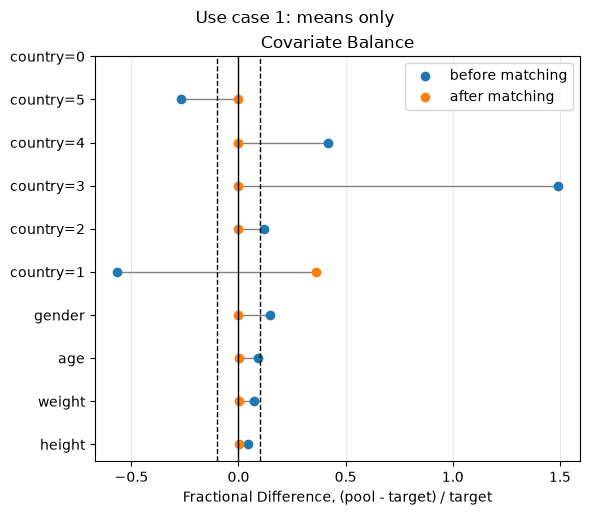

In [8]:
plot_fractional_difference(before_a, after_a)
plt.suptitle("Use case 1: means only", y=1.02);

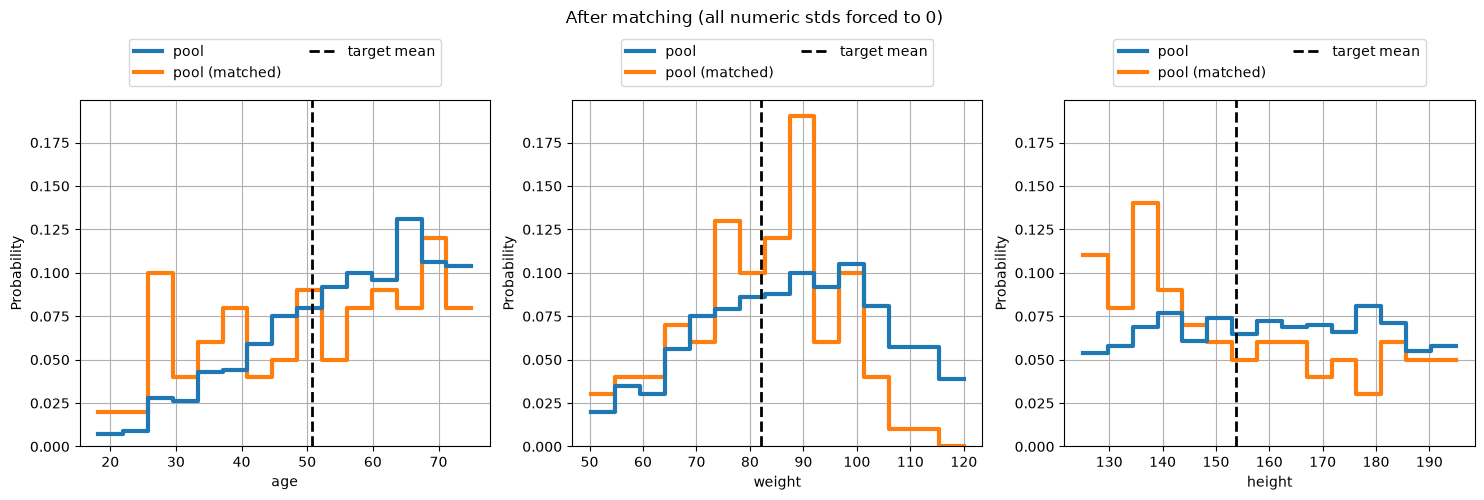

In [9]:
if 'pool (matched)' not in after_a.populations:
    before_a.append(after_a.get_population('pool'), name='pool (matched)')
plot_numeric_features(before_a, cumulative=False, bins=15, col_wrap=3)
plt.suptitle("After matching (all numeric stds forced to 0)", y=1.08);

## 4. Use case 2 -- add std constraints for numeric variables

Now `age`, `weight` and `height` each disclose their actual std too, so the matcher additionally
constrains all three variances toward their disclosed values. Every numeric feature's mean and std
should land close to its disclosed target.

In [10]:
before_b, after_b = match_with_std_mode("disclosed")

Scaling features by factor 240.00 in order to use integer solver with <= 0.4801% loss.
Scaling variance terms by factor 2 (vs. mean-term factor 240.0) so neither dominates the objective purely due to units.
Solving for match population with pool size = 100 and target size = 100 (aggregate), optimizing balance (no max_mismatch cap).
Matching on 8 dimensions ...
Building model variables and constraints ...
Calculating bounds on feature variables ...
Applying size constraints on pool ...
Applying variance constraints on 3 feature(s) with disclosed std ...
Solving with 1 workers ...
Initial balance score: 0.1745
Solution 1, time = 0.01 m
Objective:	15416.0
Balance (beta):	0.0027
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 2, time = 0.01 m
Objective:	7789.0
Balance (beta):	0.0018
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 3, time = 0.01 m
Objective:	5801.0
Balance (beta):	0.0023
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution

In [11]:
(
    before_b
        .describe(quantiles=[])
        .join(
            after_b.describe(quantiles=[]), 
            rsuffix='_matched'
        )[['pool', 'pool_matched', 'target']]
)

pool  pool_matched  target
population size N       1.000          1.00  100.00
gender          0.0     0.483          0.55    0.55
                1.0     0.517          0.45    0.45
country         1.0     0.108          0.34    0.25
                2       0.224          0.20    0.20
                3       0.274          0.11    0.11
                4       0.284          0.20    0.20
                5       0.110          0.15    0.15
                0.0       NaN           NaN    0.09
age             mean   55.520         50.91   50.80
                std    13.110         15.08   15.02
weight          mean   88.020         82.24   82.08
                std    16.550         18.84   18.72
height          mean  160.310        153.95  153.80
                std    19.500         15.80   15.72

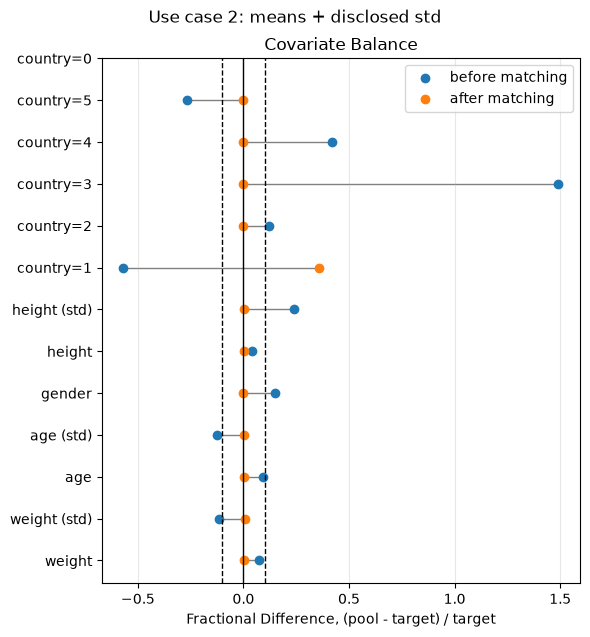

In [12]:
plot_fractional_difference(before_b, after_b)
plt.suptitle("Use case 2: means + disclosed std", y=1.02);

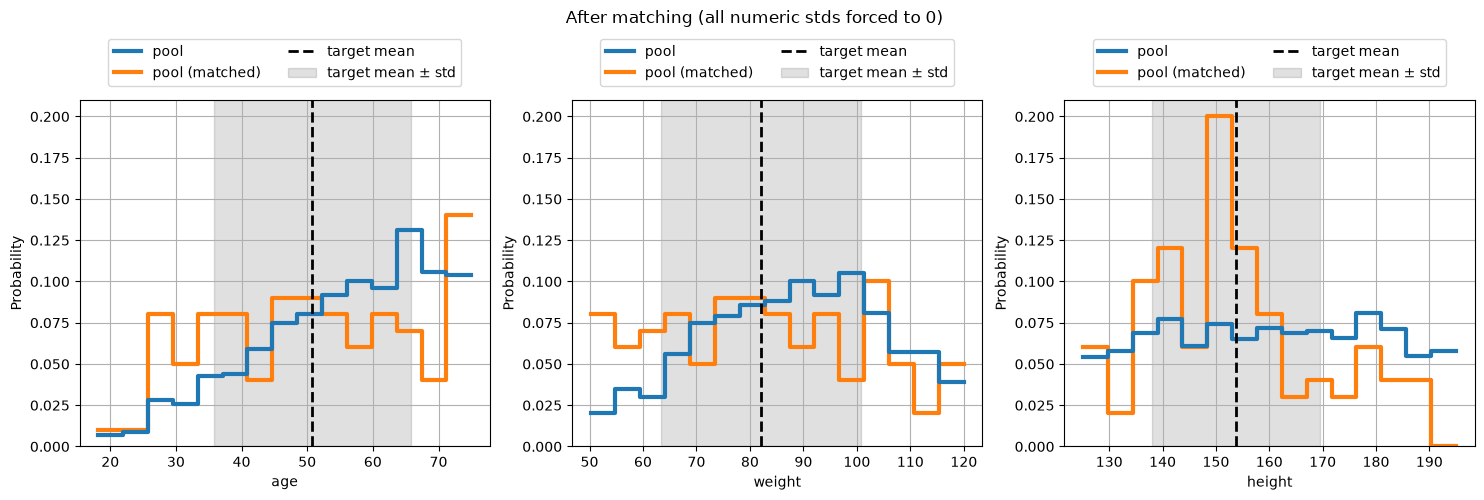

In [13]:
if 'pool (matched)' not in after_b.populations:
    before_b.append(after_b.get_population('pool'), name='pool (matched)')
plot_numeric_features(before_b, cumulative=False, bins=15, col_wrap=3)
plt.suptitle("After matching (all numeric stds forced to 0)", y=1.08);

## 5. Use case 3 -- add std=0 constraints for numeric variables

Setting every numeric feature's target std to `0` asks the solver for the **minimal-variance**
subset of the pool *simultaneously* for `age`, `weight` and `height`. All three matched stds should
collapse well below both use cases above -- while their means (and gender/country's rates) stay
just as well matched as before.

(You may see a `Detected constant feature(s) in target population: age,weight,height` warning --
that's the balance calculator flagging the zero-variance targets for its own diagnostics; it's
expected and harmless here.)

You may also notice `country`'s fractional difference (and its bar chart further down) can't be
driven to zero for every level: this toy pool structurally contains **no** `country=0` patients at
all (its generator never produces one), while the target discloses a small `country=0` rate. No
subset of the pool can conjure up a category the pool doesn't contain -- a good reminder that
subset-matching can only re-weight/re-select what's already present.

We also show the `clip` keyword on `plot_fractional_difference` here: it clips fractional
differences to `[-clip, clip]` before plotting, which is useful when a feature's target value is
close to zero (a tiny target can otherwise produce a huge fractional difference that squashes
every other feature's bar in comparison).

In [14]:
before_c, after_c = match_with_std_mode("zero")

Detected constant feature(s) in target population: age,weight,height.
Scaling features by factor 240.00 in order to use integer solver with <= 0.4801% loss.
Scaling variance terms by factor 2 (vs. mean-term factor 240.0) so neither dominates the objective purely due to units.
Solving for match population with pool size = 100 and target size = 100 (aggregate), optimizing balance (no max_mismatch cap).
Matching on 8 dimensions ...
Building model variables and constraints ...
Calculating bounds on feature variables ...
Applying size constraints on pool ...
Applying variance constraints on 3 feature(s) with disclosed std ...
Solving with 1 workers ...
Initial balance score: 0.2143
Solution 1, time = 0.01 m
Objective:	199450.0
Balance (beta):	0.0069
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 2, time = 0.01 m
Objective:	197682.0
Balance (beta):	0.0056
Patients (pool):	100
Patients (target):	100 (aggregate)
 
Solution 3, time = 0.01 m
Objective:	196910.0
Balance (beta)

In [15]:
(
    before_c
        .describe(quantiles=[])
        .join(
            after_c.describe(quantiles=[]), 
            rsuffix='_matched'
        )[['pool', 'pool_matched', 'target']]
)

pool  pool_matched  target
population size N       1.000          1.00  100.00
gender          0.0     0.483          0.55    0.55
                1.0     0.517          0.45    0.45
country         1.0     0.108          0.34    0.25
                2       0.224          0.20    0.20
                3       0.274          0.11    0.11
                4       0.284          0.20    0.20
                5       0.110          0.15    0.15
                0.0       NaN           NaN    0.09
age             mean   55.520         50.92   50.80
                std    13.110          7.63    0.00
weight          mean   88.020         82.22   82.08
                std    16.550          7.77    0.00
height          mean  160.310        153.94  153.80
                std    19.500          9.55    0.00

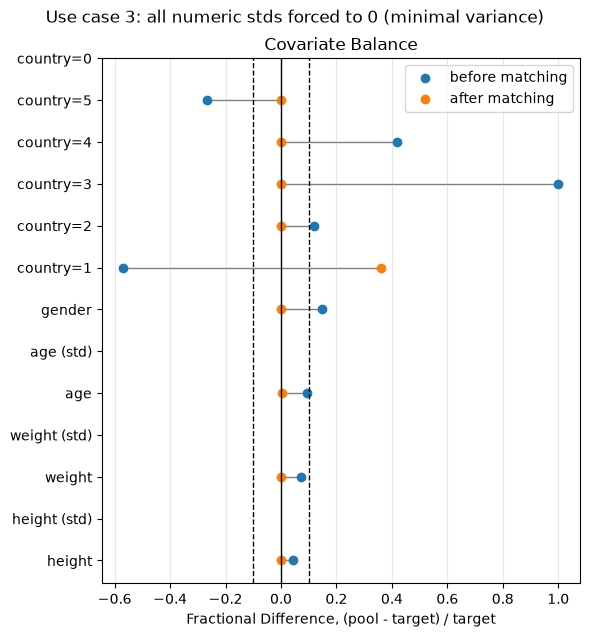

In [16]:
plot_fractional_difference(before_c, after_c, clip=1.0)
plt.suptitle("Use case 3: all numeric stds forced to 0 (minimal variance)", y=1.02);

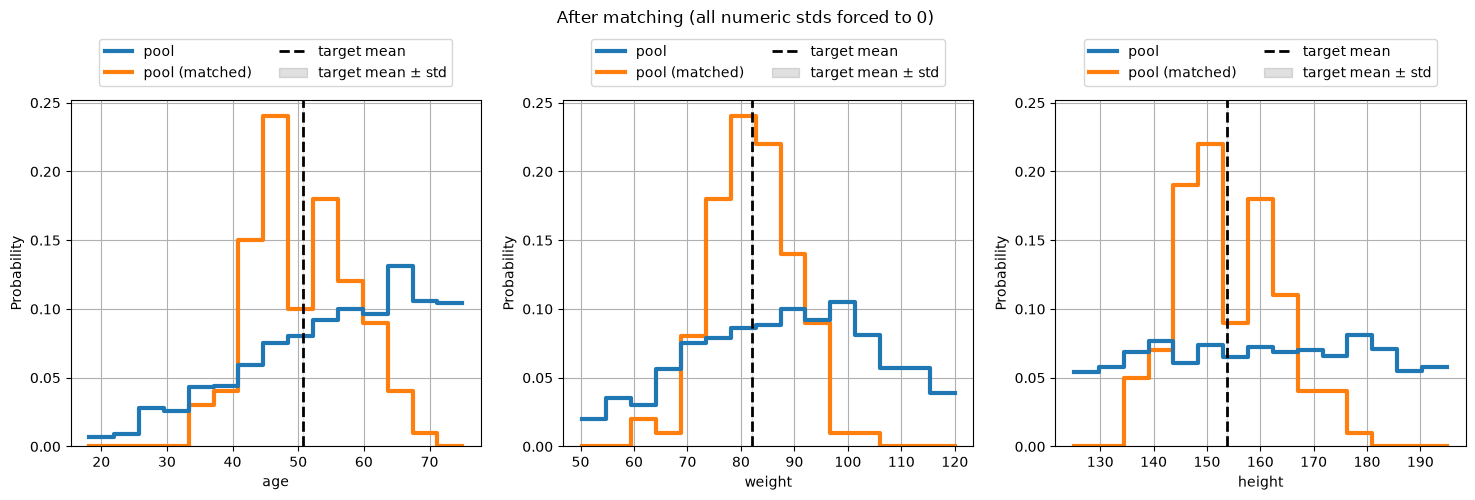

In [17]:
if 'pool (matched)' not in after_c.populations:
    before_c.append(after_c.get_population('pool'), name='pool (matched)')
plot_numeric_features(before_c, cumulative=False, bins=15, col_wrap=3)
plt.suptitle("After matching (all numeric stds forced to 0)", y=1.08);

## Takeaways

- `AggregateTarget` only needs a **mean** per numeric feature; a **std** is optional and, when
  given, adds a variance constraint the solver actually enforces (it's linear in the decision
  variables, so this is cheap for the CP-SAT solver).
- Across use cases 1-3, every feature's **mean** stays well matched throughout -- disclosing/
  constraining variance doesn't come at the expense of mean-matching elsewhere. That's a
  consequence of how the two objective terms are scaled to be commensurate internally.
- A disclosed std of `0` is a simple way to ask "give me the most homogeneous subset of the pool
  (for these features) that still matches everything else" -- useful for sensitivity analyses or
  finding a low-variance subgroup, and it composes across multiple features at once.